In [1]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sb

nombres=[x for x in range(1,25)]+['Resultado']
datos = pd.read_csv('german.data-numeric', sep=r'\s+', header=None, names=nombres)

In [2]:
print(datos)

# Captura de datos tomando, quitando la columna de resultados
X=datos.drop(labels=datos.columns[-1], axis=1)

     1   2  3   4  5  6  7  8  9  10  ...  16  17  18  19  20  21  22  23  24  \
0    1   6  4  12  5  5  3  4  1  67  ...   0   0   1   0   0   1   0   0   1   
1    2  48  2  60  1  3  2  2  1  22  ...   0   0   1   0   0   1   0   0   1   
2    4  12  4  21  1  4  3  3  1  49  ...   0   0   1   0   0   1   0   1   0   
3    1  42  2  79  1  4  3  4  2  45  ...   0   0   0   0   0   0   0   0   1   
4    1  24  3  49  1  3  3  4  4  53  ...   1   0   1   0   0   0   0   0   1   
..  ..  .. ..  .. .. .. .. .. ..  ..  ...  ..  ..  ..  ..  ..  ..  ..  ..  ..   
995  4  12  2  17  1  4  2  4  1  31  ...   0   0   1   0   0   1   0   1   0   
996  1  30  2  39  1  3  1  4  2  40  ...   0   1   1   0   0   1   0   0   0   
997  4  12  2   8  1  5  3  4  3  38  ...   0   0   1   0   0   1   0   0   1   
998  1  45  2  18  1  3  3  4  4  23  ...   0   0   1   0   0   0   0   0   1   
999  2  45  4  46  2  1  3  4  3  27  ...   0   1   1   0   0   1   0   0   1   

     Resultado  
0         

Varianza capturada por 2 componentes: 19.33%


<Axes: >

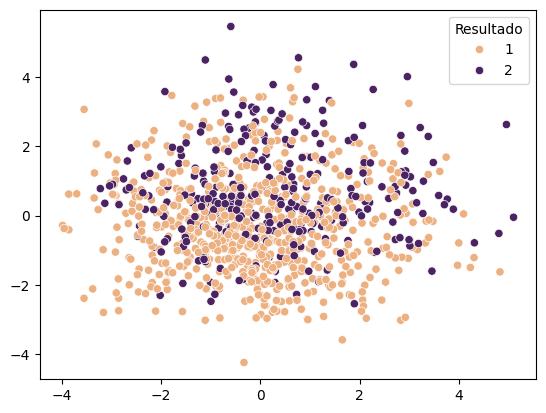

In [3]:
escal = StandardScaler()
X_escalados = escal.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalados)

# Varianza 
print(f"Varianza capturada por 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

#Gráfica
sb.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=datos['Resultado'], palette='flare')

<Axes: >

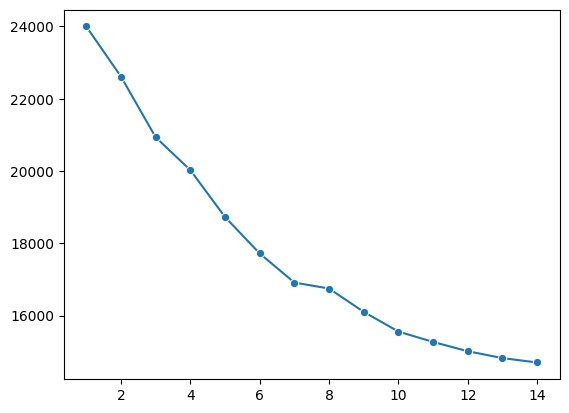

In [4]:
from sklearn.cluster import KMeans

inercia=[]
for k in range(1,15):
    kmeans = KMeans(n_clusters=k, random_state=777)
    kmeans.fit(X_escalados)
    inercia.append(kmeans.inertia_)
sb.lineplot(x=range(1,15), y=inercia, marker='o')


<Axes: >

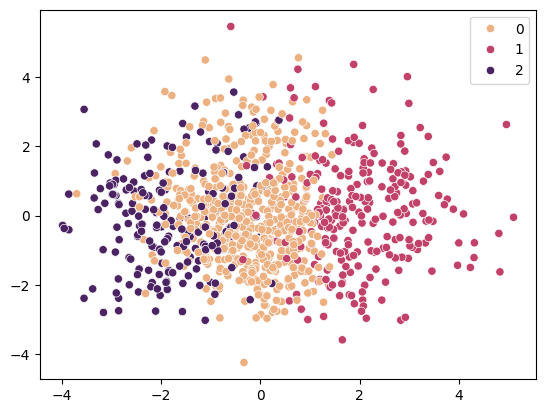

In [5]:
kmeans = KMeans(n_clusters=3, random_state=777)
k_clases = kmeans.fit_predict(X_escalados)

sb.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=k_clases, palette='flare')

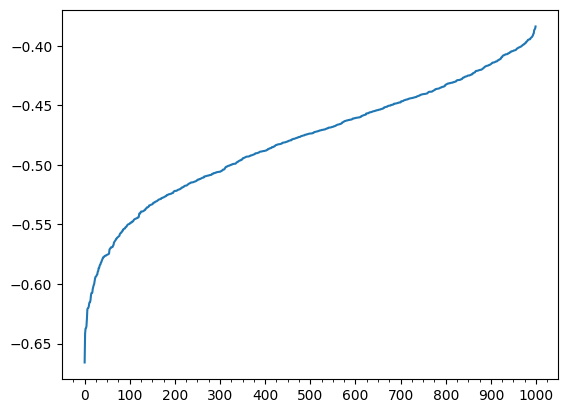

In [7]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

isoforest=IsolationForest(contamination="auto", random_state=777)
clases_isoforest=isoforest.fit_predict(X)

aux=isoforest.score_samples(X)
aux.sort()
ejes= sb.lineplot(x=range(len(aux)),y=aux, markers="o",)
ejes.xaxis.set_major_locator(ticker.MultipleLocator(100))
ejes.xaxis.set_minor_locator(ticker.MultipleLocator(25))
plt.show()

<Axes: >

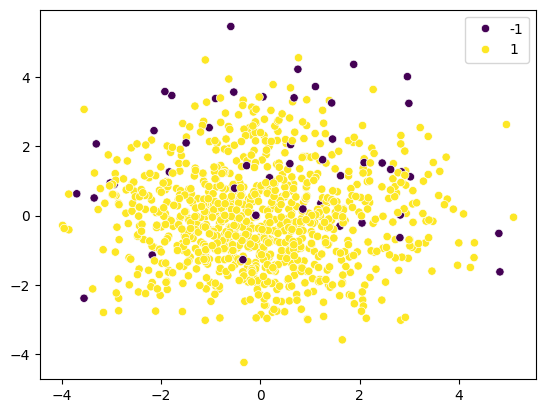

In [8]:
isoforest=IsolationForest(contamination=0.05,random_state=777)
clases_isoforest=isoforest.fit_predict(X)

sb.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=clases_isoforest, palette="viridis")

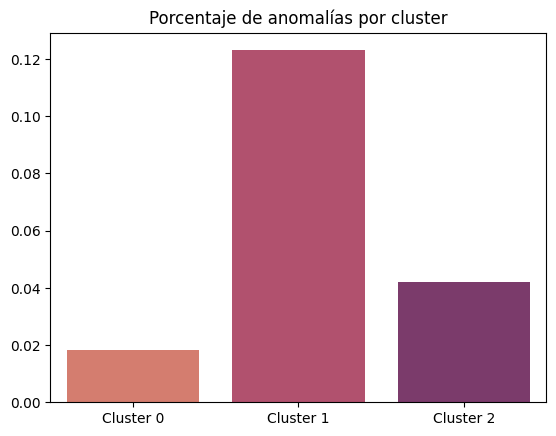

In [10]:
porcentaje_kmeans_isolation=[0,0,0]

no_supervisado=pd.DataFrame(
    {
        "K_Means": k_clases,
        "Isolatio_Forest": clases_isoforest
    }
)

interseccion = no_supervisado[no_supervisado['Isolatio_Forest'] == -1]

porcentaje_kmeans_isolation[0]=(interseccion['K_Means']==0).sum()/((k_clases==0).sum())
porcentaje_kmeans_isolation[1]=(interseccion['K_Means']==1).sum()/((k_clases==1).sum())
porcentaje_kmeans_isolation[2]=(interseccion['K_Means']==2).sum()/((k_clases==2).sum())

tabla=sb.barplot(x=["Cluster 0","Cluster 1","Cluster 2"],y=porcentaje_kmeans_isolation, hue=["Cluster 0", "Cluster 1", "Cluster 2"], palette="flare")
tabla.set(title="Porcentaje de anomalías por cluster")
plt.show()

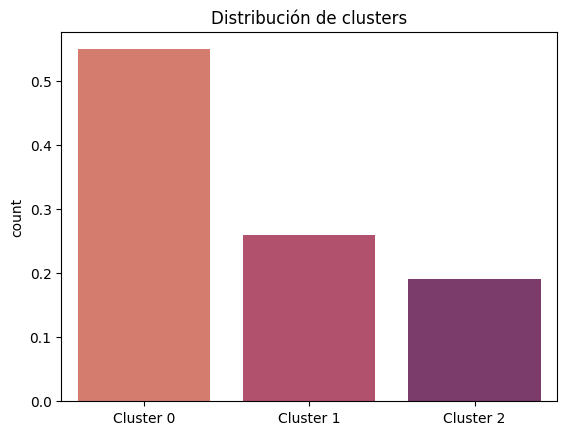

In [11]:
proba_cluster=no_supervisado["K_Means"].value_counts()/len(no_supervisado)
proba_anomalia=(no_supervisado["Isolatio_Forest"]==-1).sum()/len(no_supervisado)

tabla=sb.barplot(x=["Cluster 0","Cluster 1","Cluster 2"],y=proba_cluster, hue=["Cluster 0", "Cluster 1", "Cluster 2"], palette="flare")
tabla.set(title="Distribución de clusters")
plt.show()

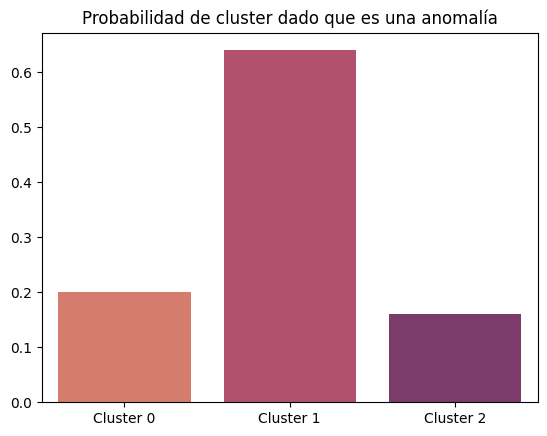

In [13]:
probabilidad_bayes=[0,0,0]

probabilidad_bayes[0]=(porcentaje_kmeans_isolation[0]*proba_cluster[0])/proba_anomalia
probabilidad_bayes[1]=(porcentaje_kmeans_isolation[1]*proba_cluster[1])/proba_anomalia
probabilidad_bayes[2]=(porcentaje_kmeans_isolation[2]*proba_cluster[2])/proba_anomalia

tabla=sb.barplot(x=["Cluster 0","Cluster 1","Cluster 2"],y=probabilidad_bayes, hue=["Cluster 0", "Cluster 1", "Cluster 2"], palette="flare")
tabla.set(title="Probabilidad de cluster dado que es una anomalía")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X=datos.drop("Resultado", axis=1)
Y=datos["Resultado"]

X.shape, Y.shape

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.25, random_state=777)



In [15]:
from sklearn.ensemble import RandomForestClassifier

ranForest=RandomForestClassifier(random_state=777, max_depth=10)
ranForest.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [16]:
from sklearn.metrics import accuracy_score


Z=ranForest.predict(X_train)
print(f"Precisión en entrenamiento: {accuracy_score(Y_train,Z):.2%}")
Z=ranForest.predict(X_test)
print(f"Precisión en prueba: {accuracy_score(Y_test,Z):.2%}")

Precisión en entrenamiento: 97.33%
Precisión en prueba: 77.20%


In [17]:
ranForest=RandomForestClassifier(random_state=777, max_depth=8, min_samples_split=5, min_samples_leaf=5)
ranForest.fit(X_train, Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [18]:
Z=ranForest.predict(X_train)
print(f"Precisión en entrenamiento: {accuracy_score(Y_train,Z):.2%}")
Z=ranForest.predict(X_test)
print(f"Precisión en prueba: {accuracy_score(Y_test,Z):.2%}")

Precisión en entrenamiento: 85.60%
Precisión en prueba: 80.80%


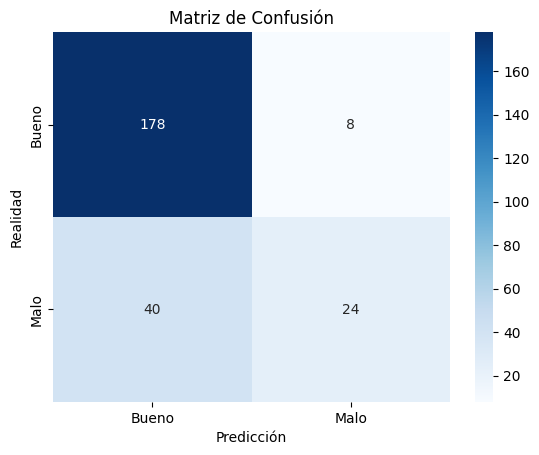

In [19]:
from sklearn.metrics import confusion_matrix

mtrx=confusion_matrix(Y_test,Z)

sb.heatmap(mtrx, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Bueno', 'Malo'],
            yticklabels=['Bueno', 'Malo'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.show()

In [20]:
print(mtrx)

VP=mtrx[0,0]
FP=mtrx[1,0]
VN=mtrx[1,1]
FN=mtrx[0,1]

Exactitud=(VP+VN)/mtrx.sum()
print(f"Exactitud: {Exactitud:.2%}")
Prevalencia=(VP+FP)/mtrx.sum()
print(f"Prevalencia: {Prevalencia:.2%}")
Sensibilidad=VP/(VP+FN)
print(f"Sensibilidad: {Sensibilidad:.2%}")
Especificidad=VN/(VN+FP)
print(f"Especificidad: {Especificidad:.2%}")
Precision=VP/(VP+FP)
print(f"Precision: {Precision:.2%}")



[[178   8]
 [ 40  24]]
Exactitud: 80.80%
Prevalencia: 87.20%
Sensibilidad: 95.70%
Especificidad: 37.50%
Precision: 81.65%


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gradBoost=GradientBoostingClassifier(random_state=777)
gradBoost.fit(X_train, Y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [22]:
Z=gradBoost.predict(X_train)
print(f"Precisión en entrenamiento: {accuracy_score(Y_train,Z):.2%}")
Z=gradBoost.predict(X_test)
print(f"Precisión en prueba: {accuracy_score(Y_test,Z):.2%}")


Precisión en entrenamiento: 90.27%
Precisión en prueba: 78.00%


In [23]:
gradBoost=GradientBoostingClassifier(random_state=777, max_depth=5, min_samples_split=3, subsample=0.7, learning_rate=0.01)
gradBoost.fit(X_train, Y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.7
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [24]:
Z=gradBoost.predict(X_train)
print(f"Precisión en entrenamiento: {accuracy_score(Y_train,Z):.2%}")
Z=gradBoost.predict(X_test)
print(f"Precisión en prueba: {accuracy_score(Y_test,Z):.2%}")

Precisión en entrenamiento: 84.27%
Precisión en prueba: 78.00%


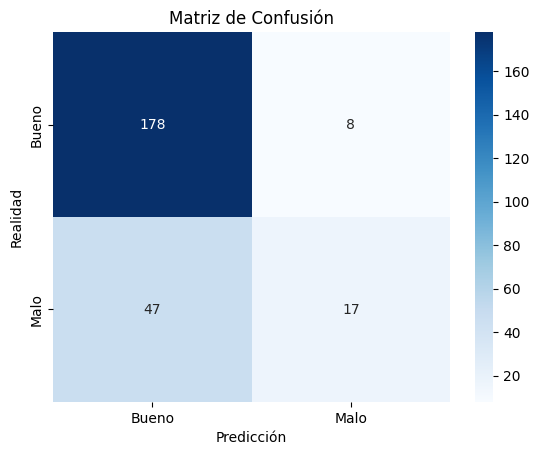

In [26]:
mtrx=confusion_matrix(Y_test,Z)

sb.heatmap(mtrx, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Bueno', 'Malo'],
            yticklabels=['Bueno', 'Malo'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.show()

In [27]:
print(mtrx)

VP=mtrx[0,0]
FP=mtrx[1,0]
VN=mtrx[1,1]
FN=mtrx[0,1]

Exactitud=(VP+VN)/mtrx.sum()
print(f"Exactitud: {Exactitud:.2%}")
Prevalencia=(VP+FP)/mtrx.sum()
print(f"Prevalencia: {Prevalencia:.2%}")
Sensibilidad=VP/(VP+FN)
print(f"Sensibilidad: {Sensibilidad:.2%}")
Especificidad=VN/(VN+FP)
print(f"Especificidad: {Especificidad:.2%}")
Precision=VP/(VP+FP)
print(f"Precision: {Precision:.2%}")

[[178   8]
 [ 47  17]]
Exactitud: 78.00%
Prevalencia: 90.00%
Sensibilidad: 95.70%
Especificidad: 26.56%
Precision: 79.11%


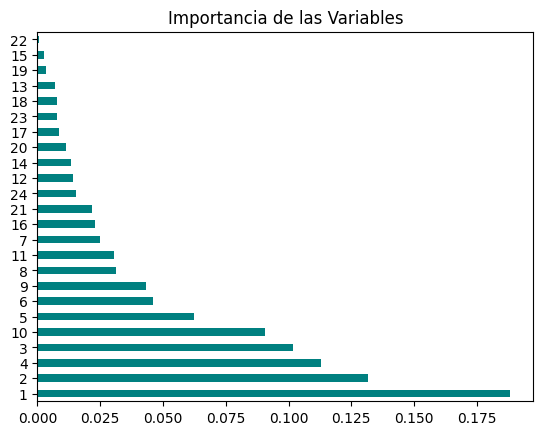

In [28]:
importancias = ranForest.feature_importances_
nombres_columnas = X.columns

feat_imp = pd.Series(importancias, index=nombres_columnas).sort_values(ascending=False)
feat_imp.plot(kind='barh', color='teal')
plt.title("Importancia de las Variables")
plt.show()

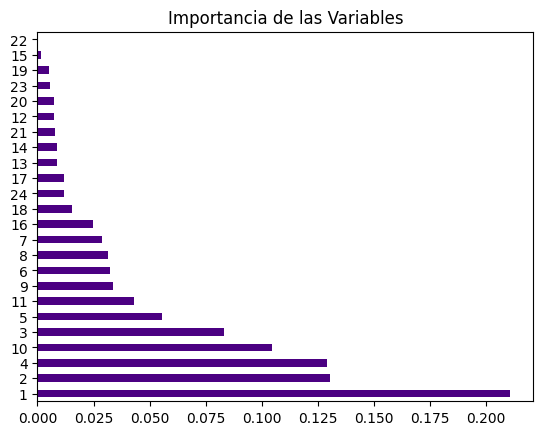

In [29]:
importancias = gradBoost.feature_importances_

feat_imp = pd.Series(importancias, index=nombres_columnas).sort_values(ascending=False)
feat_imp.plot(kind='barh', color='indigo')
plt.title("Importancia de las Variables")
plt.show()